## Diversity-metric sweep analysis

This notebook loads all `04_diversity_metric*.json` artifacts, extracts `(model, temperature, prompt_type)`, builds a dataframe containing the **six** diversity metrics, and plots each metric vs temperature.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns

    _HAVE_SEABORN = True
except Exception:
    sns = None
    _HAVE_SEABORN = False


REPO_ROOT = Path.cwd()
OUTPUTS_DIR = REPO_ROOT / "Persona_Generator" / "outputs"

# Match strings like:
#   02c_stage2_personas_llama-3.1-405b-instructT0.0_default.json
# Captures:
#   model = llama-3.1-405b-instruct
#   temp = 0.0
#   prompt_type = default
_STAGE2_RE = re.compile(
    r"^02c_stage2_personas_(?P<model>.+?)T(?P<temp>[0-9]*\.?[0-9]+)_(?P<prompt_type>[^.]+)\.json$"
)

# Legacy/older naming without temperature, e.g.:
#   02c_stage2_personas_llama-3.1-405b_fewshot.json
_STAGE2_LEGACY_RE = re.compile(
    r"^02c_stage2_personas_(?P<model>.+?)_(?P<prompt_type>[^.]+)\.json$"
)


METRIC_COLS = [
    "coverage",
    "convex_hull_volume",
    "min_pairwise_distance",
    "mean_pairwise_distance",
    "dispersion",
    "kl_divergence",
]


def _parse_stage2_id(stage2_filename: str) -> dict:
    m = _STAGE2_RE.match(stage2_filename)
    if m:
        return {
            "model": m.group("model"),
            "temp": float(m.group("temp")),
            "prompt_type": m.group("prompt_type"),
        }

    m = _STAGE2_LEGACY_RE.match(stage2_filename)
    if m:
        return {
            "model": m.group("model"),
            "temp": float("nan"),
            "prompt_type": m.group("prompt_type"),
        }

    return {"model": "unknown", "temp": float("nan"), "prompt_type": "unknown"}


def load_diversity_metric_artifacts(base_dir: Path) -> pd.DataFrame:
    files = sorted(base_dir.rglob("04_diversity_metric*.json"))
    if not files:
        raise FileNotFoundError(f"No files matching 04_diversity_metric*.json under {base_dir}")

    rows: list[dict] = []
    for p in files:
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)

        metrics = data.get("metrics", {})

        # Preferred source: stored stage2_file inside the JSON artifact.
        stage2_file = data.get("stage2_file")
        parsed = _parse_stage2_id(stage2_file) if isinstance(stage2_file, str) else None

        # Fallback to the diversity metrics filename.
        if not parsed:
            parsed = _parse_stage2_id(p.name)

        row = {
            "artifact_path": str(p.relative_to(REPO_ROOT)),
            "stage2_file": stage2_file,
            **parsed,
        }

        for k in METRIC_COLS:
            row[k] = float(metrics.get(k)) if k in metrics else float("nan")

        rows.append(row)

    df = pd.DataFrame(rows)

    # Stable legend label
    df["model_prompt"] = df["model"].astype(str) + "+" + df["prompt_type"].astype(str)

    # Keep numeric ordering for plots
    df = df.sort_values(["model_prompt", "temp"], na_position="last").reset_index(drop=True)

    return df


df = load_diversity_metric_artifacts(OUTPUTS_DIR)
print(f"Loaded {len(df)} artifact(s) from {OUTPUTS_DIR}")
df

Loaded 11 artifact(s) from c:\Users\G25971483\Desktop\Projects\recover_entropy_collapse\Persona_Generator\outputs


,artifact_path,stage2_file,model,temp,prompt_type,coverage,convex_hull_volume,min_pairwise_distance,mean_pairwise_distance,dispersion,kl_divergence,model_prompt
0,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0.0_autobio...,llama-3.1-405b,0.0,autobiographical,0.8214,0.071181,0.0,0.401011,0.667372,0.843389,llama-3.1-405b+autobiographical
1,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0.5_autobio...,llama-3.1-405b,0.5,autobiographical,0.7860,0.054109,0.0,0.358128,0.702314,0.918099,llama-3.1-405b+autobiographical
2,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0.9_autobio...,llama-3.1-405b,0.9,autobiographical,0.7357,0.036844,0.0,0.270934,0.738880,1.194907,llama-3.1-405b+autobiographical
3,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0_fewshot.json,llama-3.1-405b,0.0,fewshot,0.8453,0.128183,0.0,0.386029,0.661606,1.061055,llama-3.1-405b+fewshot
4,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0.5_fewshot...,llama-3.1-405b,0.5,fewshot,0.7389,0.032504,0.0,0.263082,0.694235,1.391224,llama-3.1-405b+fewshot
5,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405bT0.9_fewshot...,llama-3.1-405b,0.9,fewshot,0.6843,0.037423,0.0,0.251527,0.777733,1.499991,llama-3.1-405b+fewshot
6,Persona_Generator\outputs\old\04_diversity_met...,02c_stage2_personas_llama-3.1-405b_fewshot.json,llama-3.1-405b,NaN,fewshot,0.8066,0.177083,0.0,0.487088,0.619339,0.978864,llama-3.1-405b+fewshot
7,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405b-instructT0....,llama-3.1-405b-instruct,0.0,default,0.7550,0.041281,0.0,0.298764,0.710463,1.191733,llama-3.1-405b-instruct+default
8,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405b-instructT0....,llama-3.1-405b-instruct,0.5,default,0.7163,0.026138,0.0,0.265062,0.690210,1.250724,llama-3.1-405b-instruct+default
9,Persona_Generator\outputs\04_diversity_metric_...,02c_stage2_personas_llama-3.1-405b-instructT0....,llama-3.1-405b-instruct,0.9,default,0.7205,0.025849,0.0,0.284991,0.669389,1.229712,llama-3.1-405b-instruct+default


In [2]:
# Filter to runs with a temperature (required for x-axis)
plot_df = df.copy()
plot_df["temp"] = pd.to_numeric(plot_df["temp"], errors="coerce")
plot_df = plot_df.dropna(subset=["temp"]).copy()

if len(plot_df) == 0:
    raise ValueError("No artifacts with a parseable temperature were found.")

print(f"Plotting {len(plot_df)} artifact(s) with parseable temperature")
plot_df[["artifact_path", "model", "temp", "prompt_type", "model_prompt"] + METRIC_COLS]

Plotting 9 artifact(s) with parseable temperature


,artifact_path,model,temp,prompt_type,model_prompt,coverage,convex_hull_volume,min_pairwise_distance,mean_pairwise_distance,dispersion,kl_divergence
0,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.0,autobiographical,llama-3.1-405b+autobiographical,0.8214,0.071181,0.0,0.401011,0.667372,0.843389
1,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.5,autobiographical,llama-3.1-405b+autobiographical,0.7860,0.054109,0.0,0.358128,0.702314,0.918099
2,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.9,autobiographical,llama-3.1-405b+autobiographical,0.7357,0.036844,0.0,0.270934,0.738880,1.194907
3,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.0,fewshot,llama-3.1-405b+fewshot,0.8453,0.128183,0.0,0.386029,0.661606,1.061055
4,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.5,fewshot,llama-3.1-405b+fewshot,0.7389,0.032504,0.0,0.263082,0.694235,1.391224
5,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b,0.9,fewshot,llama-3.1-405b+fewshot,0.6843,0.037423,0.0,0.251527,0.777733,1.499991
7,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b-instruct,0.0,default,llama-3.1-405b-instruct+default,0.7550,0.041281,0.0,0.298764,0.710463,1.191733
8,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b-instruct,0.5,default,llama-3.1-405b-instruct+default,0.7163,0.026138,0.0,0.265062,0.690210,1.250724
9,Persona_Generator\outputs\04_diversity_metric_...,llama-3.1-405b-instruct,0.9,default,llama-3.1-405b-instruct+default,0.7205,0.025849,0.0,0.284991,0.669389,1.229712


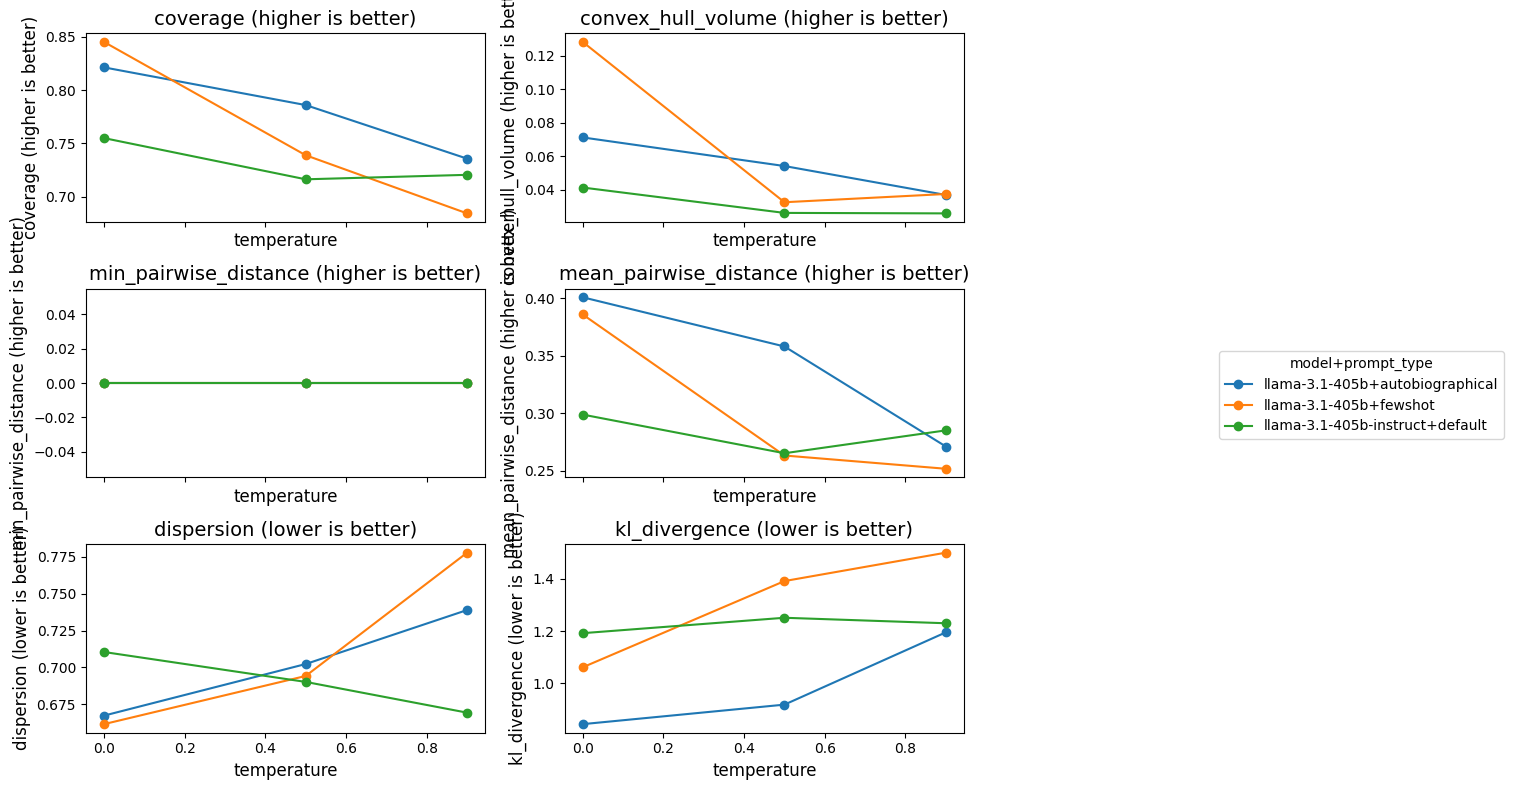

In [5]:
METRIC_DIRECTION = {
    "coverage": "higher",
    "convex_hull_volume": "higher",
    "min_pairwise_distance": "higher",
    "mean_pairwise_distance": "higher",
    "dispersion": "lower",
    "kl_divergence": "lower",
    # composite score that we will add later
    "mean_normalized_diversity_score": "higher",
}


def _setup_style():
    if _HAVE_SEABORN:
        sns.set_theme(style="whitegrid")
    plt.rcParams.update(
        {
            "figure.figsize": (12, 8),
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "legend.fontsize": 10,
        }
    )


def plot_metric_on_axis(metric: str, data: pd.DataFrame, ax: plt.Axes) -> None:
    if metric not in data.columns:
        raise KeyError(f"Missing metric column: {metric}")

    direction = METRIC_DIRECTION.get(metric, "higher")

    if _HAVE_SEABORN:
        sns.lineplot(
            data=data,
            x="temp",
            y=metric,
            hue="model_prompt",
            marker="o",
            ax=ax,
            legend=False,
        )
    else:
        for label, g in data.groupby("model_prompt", sort=False):
            g = g.sort_values("temp")
            ax.plot(g["temp"], g[metric], marker="o", label=label)

    ax.set_title(f"{metric} ({direction} is better)")
    ax.set_xlabel("temperature")
    ax.set_ylabel(f"{metric} ({direction} is better)")


def plot_metrics_grid(metrics: list[str], data: pd.DataFrame) -> None:
    _setup_style()

    n_rows, n_cols = 3, 2
    fig, axes = plt.subplots(n_rows, n_cols, sharex=True)
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, metrics):
        plot_metric_on_axis(metric, data, ax)

    # Hide any unused subplots if metrics < 3*2
    for ax in axes_flat[len(metrics) :]:
        ax.axis("off")

    # Build a single legend for the whole figure
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if not handles:
        # If seaborn handled legend per-axis, reconstruct from grouped data
        for label, g in data.groupby("model_prompt", sort=False):
            handles.append(plt.Line2D([], [], marker="o", linestyle="-"))
            labels.append(label)

    fig.legend(
        handles,
        labels,
        title="model+prompt_type",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0.0,
    )

    plt.tight_layout(rect=(0, 0, 0.82, 1))
    plt.show()


plot_metrics_grid(METRIC_COLS, plot_df)

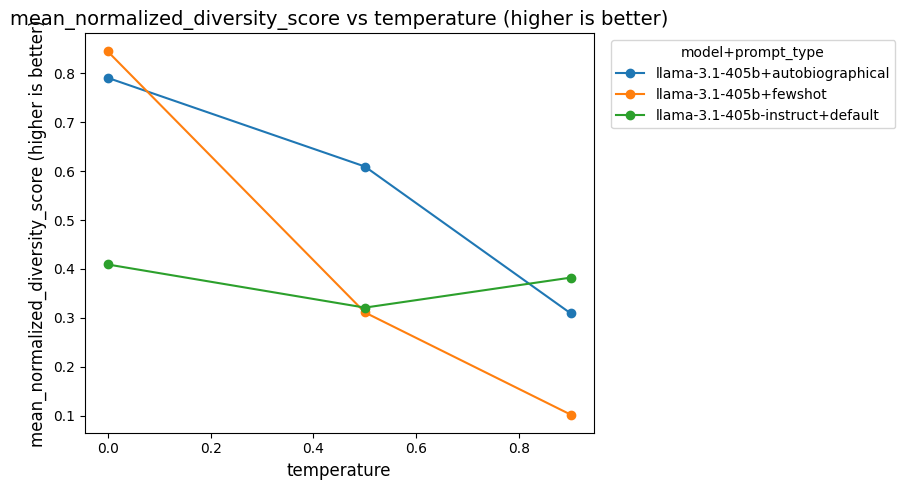

In [4]:
# Direction-aware normalized composite across the 6 metrics.
# For higher-is-better metrics we use min-max normalization;
# for lower-is-better metrics we invert after normalization so that
# larger values always mean better performance before averaging.

norm_df = plot_df.copy()
lower_is_better = {"dispersion", "kl_divergence"}

for metric in METRIC_COLS:
    vals = pd.to_numeric(norm_df[metric], errors="coerce")
    vmin = vals.min()
    vmax = vals.max()

    if pd.isna(vmin) or pd.isna(vmax):
        norm_vals = pd.Series(pd.NA, index=vals.index)
    elif vmax == vmin:
        # If there is no variation, treat all runs as neutral (0.5)
        norm_vals = pd.Series(0.5, index=vals.index)
    else:
        if metric in lower_is_better:
            # lower is better → invert so higher is better
            norm_vals = (vmax - vals) / (vmax - vmin)
        else:
            norm_vals = (vals - vmin) / (vmax - vmin)

    norm_df[f"{metric}_norm"] = norm_vals

norm_cols = [f"{m}_norm" for m in METRIC_COLS]
norm_df["mean_normalized_diversity_score"] = norm_df[norm_cols].mean(axis=1, skipna=True)

plot_metric_vs_temp("mean_normalized_diversity_score", norm_df)